# Introduction

In this notebook, we are going to:
- check for potential feature distribution shifts between train and test sets, that we've discovered in previous notebook ``08_classification_model_selection.ipynb``;
- make severity and prediction EHF distribution analysis of selected model;
- calibrate our model's probabilities with *"Platt Scaling with CV"* method;
- compare raw and calibrated probabilities;
- find out optimal threshold value in favor of *recall* metric.

# Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import random
import ast

from xgboost import XGBClassifier

# Import util functions
from src.modelling_utils import (
                                get_classification_metrics,
                                train_test_with_groups_and_pca, 
                                adjust_pr_curve_from_roc,
                                optimize_threshold_cv
                                )
from src.plotting_utils import (
                                plot_precision_recall_curve, 
                                plot_roc_curve, 
                                plot_ehf_proba,
                                probability_severity_distribution
                                )

from sklearn.metrics import brier_score_loss
from src.calibration_utils import (
                                XGBCalibrated, 
                                plot_calibration_curves, 
                                expected_calibration_error,
                                ece_binary_with_bins
                                )

RANDOM_STATE = 4 # For reproducibility

# Data Loading and Initial Processing

In [2]:
all_feats_df = pd.read_csv("data/processed/daily_all_features.csv", index_col="datetime_local")
all_feats_df.index = pd.to_datetime(all_feats_df.index, utc=True).tz_convert("Australia/Adelaide")
all_feats_df.head()

,relative_humidity_2m,dew_point_2m,apparent_temperature,pressure_msl,wind_speed_10m,cloud_cover,shortwave_radiation,wet_bulb_temperature_2m,month_local,wind_unit_x,...,month_cyc_x,month_cyc_y,DMT_month_mean,tmin_month_mean,tmax_month_mean,EHF_month_mean,EHI_sig_month_mean,EHF_sev_month_mean,relative_humidity_2m_month_mean,DMT_avg30
datetime_local,,,,,,,,,,,,,,,,,,,,,
2000-01-01 00:00:00+10:30,58.375954,6.854583,11.690625,1018.404172,22.481411,25.791667,338.208333,10.507936,1.0,-0.859000,...,0.866025,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-02 00:00:00+10:30,53.894292,8.606667,17.562999,1014.966667,13.889992,17.791667,381.666667,13.051835,1.0,-0.590170,...,0.866025,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-03 00:00:00+10:30,59.922957,10.537917,17.466684,1013.208338,17.923586,18.916667,377.500000,14.051188,1.0,-0.738965,...,0.866025,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-04 00:00:00+10:30,51.373941,5.492083,11.487354,1020.416664,27.433249,17.791667,379.583333,10.278888,1.0,-0.985043,...,0.866025,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-05 00:00:00+10:30,54.446861,6.762917,12.839374,1022.775004,21.999236,32.166667,361.125000,10.918418,1.0,-0.904516,...,0.866025,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
daily_df = pd.read_csv("data/processed/adelaide_daily_weather_cleaned.csv", index_col="datetime_local")
daily_df.index = pd.to_datetime(daily_df.index, utc=True).tz_convert("Australia/Adelaide")

In [4]:
fg_cls= pd.read_csv('data/modelling_info/fg_cls.csv')
fg_cls

,feature_group,group_size,cumulative_pve,to_be_used_pcs
0,"['precipitation_sum7', 'precipitation_std7']",2,"[0.9635903670948435, 1.0]",1
1,"['precipitation_sum3', 'precipitation_std3']",2,"[0.9519504301550225, 0.9999999999999999]",1
2,"['wind_speed_10m_lag2', 'wind_speed_10m_avg3']",2,"[0.9269007706676774, 0.9999999999999999]",1
3,"['EHI_accl_lag3', 'EHI_accl_lag4']",2,"[0.9302000255077699, 1.0]",1
4,"['DMT_std3', 'tmax_std3']",2,"[0.9459727593038323, 1.0]",1
5,"['pressure_msl_lag1', 'pressure_msl_lag2', 'pr...",3,"[0.909740388413776, 0.9902699932238705, 1.0]",1
6,"['pressure_msl_lag3', 'pressure_msl_avg7']",2,"[0.8955354159430747, 0.9999999999999999]",1
7,"['DMT_std7', 'tmin_std7', 'tmax_std7', 'EHI_si...",4,"[0.871257895032853, 0.9461741317268824, 0.9979...",1
8,"['EHF_lag3', 'EHF_avg3', 'EHF_avg7']",3,"[0.9143955048675078, 0.9651845997143979, 0.999...",1
9,"['EHF_lag4', 'EHF_lag5']",2,"[0.9182199172946198, 1.0000000000000002]",1


In [5]:
# Drop columns
unusable_cols = ['DMT', 'tmin', 'EHF', 'EHI_sig', 'EHI_accl', 'EHF_sev', 
                               'wind_direction_compass', 'month_local']
all_feats_df.drop(columns=unusable_cols, inplace=True)

In [6]:
non_standardized_features =  ['month_cyc_x', 'month_cyc_y']
for c in all_feats_df.columns:
    if c.startswith('wind_unit') and 'avg' in c:
        non_standardized_features.append(c)

In [7]:
rank_df = pd.read_csv("data/modelling_info/feature_rank_df.csv")

In [9]:
only_linear_features = rank_df.loc[rank_df['linear_feat'] & ~rank_df['nonlinear_feat'], :].sort_values('logreg_rank', ascending=False).drop(columns=['linear_feat', 'nonlinear_feat'])
# Don't use at nonlinear models

only_nonlinear_features = rank_df.loc[rank_df['nonlinear_feat'] & ~rank_df['linear_feat'], :].sort_values('gradboost_rank', ascending=False).drop(columns=['linear_feat', 'nonlinear_feat'])
# Don't use at linear models

not_used_both = rank_df.loc[~rank_df['nonlinear_feat'] & ~rank_df['linear_feat'], :].sort_values('avg_rank').drop(columns=['linear_feat', 'nonlinear_feat'])
# Don't use at both type of models

In [10]:
not_to_be_used_at_linear = only_nonlinear_features['feature'].to_list() + not_used_both['feature'].to_list()
not_to_be_used_at_nonlinear = only_linear_features['feature'].to_list() + not_used_both['feature'].to_list()

In [11]:
all_feats_df.dropna(inplace=True)
y = all_feats_df['heat_wave']
X = all_feats_df.drop(columns=['severity', 'heat_wave'])

# Train and test sets
X_train = X.loc[:'2020']
y_train = y.loc[:'2020']
X_test = X.loc['2021':'2024']
y_test = y.loc['2021':'2024']

# Selected Model Params and Training

We'll be using parameters and some of train-evaluation returns.

In [12]:
# Selected XGBoost model's parameters.
params = {
    'eta': 0.1, 
    'gamma': 0.1,
    'reg_lambda': 0.75, 
    'max_depth': 4, 
    'scale_pos_weight': None, 
    'n_estimators': 61,
    'seed': RANDOM_STATE, 
    'col_sample_bytree': 1, 
    'col_sample_bylevel': 1, 
    'nthread': 1}

In [13]:
xgb = XGBClassifier(eta=0.1, gamma=0.1, reg_lambda=0.75, 
                    max_depth=4, scale_pos_weight=None, 
                    n_estimators=61, seed=RANDOM_STATE, 
                    col_sample_bytree=1, col_sample_bylevel=1, nthread=1)

In [14]:
(model, 
metric_result_train, 
metric_result_test, 
artifacts) = train_test_with_groups_and_pca(
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
        model=xgb,
        feature_groups_df=fg_cls,
        non_standardized_features=non_standardized_features,
        features_not_to_be_used=not_to_be_used_at_nonlinear,
        metric_fn=get_classification_metrics,
        metric_kwargs={'target_prevalence': y_train.value_counts(normalize=True)[True]}
)

c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:12:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "col_sample_bylevel", "col_sample_bytree" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


# Feature Distribution Analysis

We are going to research on if there is any distribution shift between train and test sets. We are going to check heatwave day EHF distributions, and **Wasserstein Distance**s of heatwave/non-heatwave subsets between train and test sets for each feature. 

EHF is main numerical feature to decide whether a heatwave is exist or not. Even we don't predict directly it, its dynamics with feature space is main motivation of this modelling goal. Hence, distribution shift/drifts of it might most likely be related with model's performance. 

## EHF Comparison

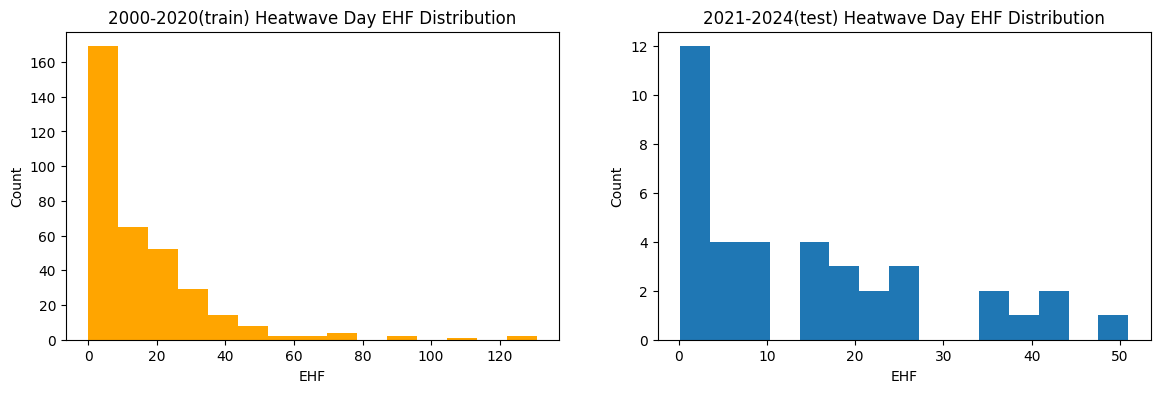

In [ ]:
ehf_2020 = daily_df.loc[:'2020', 'EHF']
ehf_2020 = ehf_2020[ehf_2020 > 0] # Only heatwave rows
ehf_21_24 = daily_df.loc['2021':'2024', 'EHF']
ehf_21_24 = ehf_21_24[ehf_21_24 > 0] # Only heatwave rows
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].set_title("2000-2020(train) Heatwave Day EHF Distribution")
ax[0].hist(ehf_2020, bins=15, color="orange")
ax[0].set_ylabel("Count")
ax[0].set_xlabel("EHF")
ax[1].set_title("2021-2024(test) Heatwave Day EHF Distribution")
ax[1].hist(ehf_21_24, bins=15)
ax[1].set_ylabel("Count")
ax[1].set_xlabel("EHF")
plt.show()

As we can see train set's heatwave EHFs take much higher values, beside the fact its frequency prevalance is higher too. We have not checked yet but model might be able to detect higher EHF heatwave days more easily. We inferred during *"EDA and Statistical Analysis"* that there are features differs by heatwave severity. As we know, by definition, severity directly related with EHF values. Thus, our hypothesis is, test performance values might have dropped due to EHF values on test time interval being low compared to training time interval. In contrary to our hypothesis, *Adjusted PR-AUC* values of full test set and CV results are consistent as we've shown above. But, they are consistent with mean of CV value. CV one standartd deviaton interval is *0.7416 ± 0.0863*, which means our hypothesis might be avoiding model's main *Test Adjusted PR-AUC* to get a value around high boundry of the interval. For example 0.8.

Thus we are going to check *whole* feature space **Wasserstein Distances** and, relation of probability scores with event severities and EHF values. We are going to focus not only used features, but all root and derived features as possible. Because our question is not only model spesific here. We are going to note feature importances too, to see how model is effected by shifts if there is any.

## Distribution Shift Analysis with Wassertein Distance

**!! Note:** This analysis performed before that we've discovered shifts migth be caused by *El Niño Southern Oscillation* during reviewing of notebook `04_heatwave_analysis.ipynb`. We want to keep this part due to eventually it is a more granular analysis of features for two time intervals and, at the end, analysis raised an other question worth to survey on in future (look last explanation cell in this section for it). 

In [ ]:
# Use returned scaler to standardize. This features contains PCA features too.
standardizable_features = list(set(X_train.columns) - set(non_standardized_features))
X_train_scaled = X_train[standardizable_features].copy()
X_test_scaled = X_test[standardizable_features].copy()

X_train_scaled[standardizable_features] = artifacts['scaler'].transform(X_train[standardizable_features])
X_test_scaled[standardizable_features] = artifacts['scaler'].transform(X_test[standardizable_features])

In [ ]:
from src.modelling_utils import extract_pcas_from_groups

pc_parts_train = []
pc_parts_test = []

# Calculating PCs by using returned PCA objects by `train_test_with_groups_and_pca` function.
_, pc_parts_train, pc_parts_test = extract_pcas_from_groups(feature_groups_df=fg_cls, 
                                                            X_train_scaled=X_train_scaled, 
                                                            X_train_parts=pc_parts_train, 
                                                            X_test_scaled=X_test_scaled,
                                                            X_test_parts=pc_parts_test,
                                                            _pcas_=artifacts['pcas'])

# Combining in one dataframe
pc_train = pd.concat(pc_parts_train, axis=1)
pc_test = pd.concat(pc_parts_test, axis=1)

In [ ]:
all_feats_df = pd.read_csv("data/processed/daily_all_features.csv", index_col="datetime_local")
all_feats_df.index = pd.to_datetime(all_feats_df.index, utc=True).tz_convert("Australia/Adelaide")
# We need all features to analysis here. Some columns are dropped during preprocessing, so we're reloading 'all_feats_df'.

In [ ]:
all_feats_df.select_dtypes(exclude=['number']).columns

Index(['wind_direction_compass', 'severity', 'heat_wave'], dtype='object')

These three are categorical features, Wasserstein Distance cannot be calculated for them. Thus, we are dropping them.

In [ ]:
# Drop categorical features
categorical_cols = all_feats_df.select_dtypes(exclude=['number']).columns
all_feats_df.drop(columns=categorical_cols, inplace=True)

In [ ]:
all_feats_df.dropna(inplace=True)
all_feats_df.index.min(), X_train.index.min()
# Start dates matches as we want.

(Timestamp('2001-01-01 00:00:00+1030', tz='Australia/Adelaide'),
 Timestamp('2001-01-01 00:00:00+1030', tz='Australia/Adelaide'))

In [ ]:
# Feature sets to be used to calculate "Wasserstein Distances".
train_set = pd.concat([all_feats_df.loc[:'2020'], pc_train], axis=1)
test_set = pd.concat([all_feats_df.loc['2021':'2024'], pc_test], axis=1) 

# Heatwave and non-heatwave subsets
h_train = train_set.copy()[y_train == True]
h_test = test_set.copy()[y_test == True]
nh_train = train_set.copy()[y_train == False]
nh_test = test_set.copy()[y_test == False]

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler_all = StandardScaler()
scaler_heatwave = StandardScaler()
scaler_non_heatwave = StandardScaler()
all_cols = list(train_set.columns)

train_set[all_cols] = scaler_all.fit_transform(train_set[all_cols])
h_train[all_cols] = scaler_heatwave.fit_transform(h_train[all_cols])
nh_train[all_cols] = scaler_non_heatwave.fit_transform(nh_train[all_cols])

test_set[all_cols] = scaler_all.transform(test_set[all_cols])
h_test[all_cols] = scaler_heatwave.transform(h_test[all_cols])
nh_test[all_cols] = scaler_non_heatwave.transform(nh_test[all_cols])

**!!** *Why do we seperate heatwave and non-heatwave subsets?*: According to *Law of Total Probability*,
$$
P(X) = P(Y=1)P(X|Y=1) + P(Y=0)P(X|Y=0), 
$$
where $X$ is our predictor random variable and $Y$ is our target binary random variable, which is 1 for heatwave and 0 for non-heatwave. $P(Y=1)$ is also called *prevalence*. According to formula $X$ distribution depends on different factors. Even any conditional probabilities equal but prevalence is different for different time periods like train and test sets, it would effect the $X$ distribution. And as we've checked above, it is. By seperating heatwave and non-heatwave subsets, we can check the change in $X$ distribution by singular factors. **!** In other words: We can check heatwave and non-heatwave times' conditions seperately and check if any climatic drift is happened actually. We've detected that test time intervals events less severe than train time intervals. In this case we can see which features are responsible for this. And by comparing their feature importances, is model really robust or not, for which type changes. Eventually, we are going to check all instances and heatwave/non-heatwave subsets in 3 group.

**!** *Why do we **standardize** them in themselves?*: By standardization, we remove unit information, so we can analyze results within a single scale. Which is actually standart deviation. We scaled them to standard deviation of 1. We've done standardizations with respect to train sets, thus variational differences and mean drifts of test sets can be seen at results.

In [ ]:
from src.general_utils import compute_wasserstein_report
wasserstein_report = compute_wasserstein_report(train_set, test_set, 
                                                h_train, h_test,
                                                nh_train, nh_test,
                                                all_cols, artifacts['feature_names'], 
                                                model.feature_importances_,
                                                n_bootstrap=30, random_state=RANDOM_STATE)

In [ ]:
wasserstein_report.describe()

,importance,w_all,w_nh,w_h_mean,w_h_std
count,168.000000,168.000000,168.000000,168.000000,168.000000
mean,0.005952,0.103906,0.098746,0.341412,0.091479
std,0.019888,0.078281,0.079455,0.109028,0.035911
min,0.000000,0.000000,0.000000,0.100400,0.000000
25%,0.000000,0.064725,0.061000,0.261400,0.066275
50%,0.000000,0.084000,0.072100,0.324900,0.088950
75%,0.006850,0.108225,0.100900,0.400400,0.117125
max,0.226400,0.530100,0.524400,0.816000,0.199700


In [ ]:
wasserstein_report # Sorted by feature importance

,feature,importance,w_all,w_nh,w_h_mean,w_h_std
0,G14_PC1,0.2264,0.0843,0.0721,0.3190,0.1182
1,wind_unit_x_avg3,0.0833,0.0896,0.1007,0.3292,0.1093
2,G8_PC1,0.0414,0.0970,0.0681,0.2943,0.0769
3,EHF_sev_lag4,0.0368,0.0617,0.0450,0.2223,0.0328
4,wind_unit_y,0.0361,0.1185,0.1258,0.3486,0.0948
...,...,...,...,...,...,...
163,month_cyc_y,0.0000,0.0000,0.0116,0.2160,0.0832
164,precipitation_std3,0.0000,0.2058,0.1984,0.2033,0.0667
165,G5_PC1,0.0000,0.0434,0.0468,0.2773,0.0753
166,G4_PC1,0.0000,0.0765,0.0719,0.2198,0.0878


* `w_h_mean` values are *mild* at overall, not very significant but not insignificant at all too. Values are the absolute reflection of the fact that test sets ``EHF`` values are gathered in a lower and shallow range. This suggests each feature actually related with *EHF*'s scale more or less, in other words, with heatwave severity when it exists.

* ``G14_PC1`` carries the most importance, since *group 14* is one of the main feature groups directly related to temperature: *"['apparent_temperature', 'tmax']"*. Sequential 10-11 features' importances are lower, but still notable somehow. So, if a feature other than `G14_PC1` had decent distance at any 3 distance groups, it would not effect the model as much as `G14_PC1`. Eventually as we can see, `G14_PC1`'s `w_all` and `w_nh` distances very low. Which means for overall instances and non-heatwave subset instances, there is no change in `G14_PC1`'s distribution. `w_h_mean` is very close to, even smaller than average `w_h_mean` value. So, it has no more or less difference compared to normal and known EHF shift between train and test sets. 

* Among high rank features there are two 13th PCA group PC: `G13_PC1` and `G13_PC3`. Both has a little higher `w_h_mean` values than average, still not very significant. These group consists of lag temperature features. Spesificially lag 3, 7 and month. It can't effect model due to their partial low importances. From analysis perspective, this lag features might give a hints and insights about dynamics between them and todays heatwave/EHF. Might worth to check in detail.

* In overall, for features model uses, `w_all`, `w_nh` and ``w_h_mean`` values small and close to average of all features'. With a few exceptions, like `G13_PC1`, `G13_PC3`, `wind_speed_10m` etc. But their importances are not high enough to effect model significantly.

* By noting the facts above and below:
    - For `w_all` and `w_nh` columns, there is not significant distance at overall.  change between train and test time intervals. 
    - We can see at *"Cumulative Feature Importances"* plot below that, first 21 features cover 75% of total importance.
    - All features have less than 0.2 partial importance after 12th feature. Which means effects are low to model.
    - `G14_PC1`'s `w_all` and `w_nh` distances are very low, `w_h_mean` has mild value. Although, this variable is directly related with temperature hence with EHF. Thus this mild distance value only matches the fact of lower EHF values at test time interval. 

, there is no actuall climatic drift that would affect model, but only heathwave events are less severe and less frequent than train time intervals. And when we add the fact of model's *PR-AUC* and *ROC-AUC* values, model generalizes overall climate condition and be able to detect lower severity heatwaves at decent degrees. We are still going to check that, which EHF intervals are predicted as heatwave in future section.

In [ ]:
fg_cls.loc[14, 'feature_group'] # Group 14 features

"['apparent_temperature', 'tmax']"

In [ ]:
fg_cls.loc[13, 'feature_group'] # Group 13 features

"['wet_bulb_temperature_2m', 'apparent_temperature_lag1', 'apparent_temperature_lag2', 'apparent_temperature_lag3', 'wet_bulb_temperature_2m_lag1', 'wet_bulb_temperature_2m_lag2', 'wet_bulb_temperature_2m_lag3', 'DMT_lag1', 'DMT_lag2', 'DMT_lag3', 'tmin_lag1', 'tmin_lag2', 'tmin_lag3', 'tmax_lag1', 'tmax_lag2', 'tmax_lag3', 'EHI_sig_lag3', 'EHI_sig_lag4', 'EHI_sig_lag5', 'DMT_avg3', 'DMT_avg7', 'tmin_avg3', 'tmin_avg7', 'tmax_avg3', 'tmax_avg7', 'EHI_sig_avg3', 'EHI_sig_avg7', 'DMT_month_mean', 'tmin_month_mean', 'tmax_month_mean', 'EHF_month_mean', 'EHI_sig_month_mean', 'relative_humidity_2m_month_mean']"

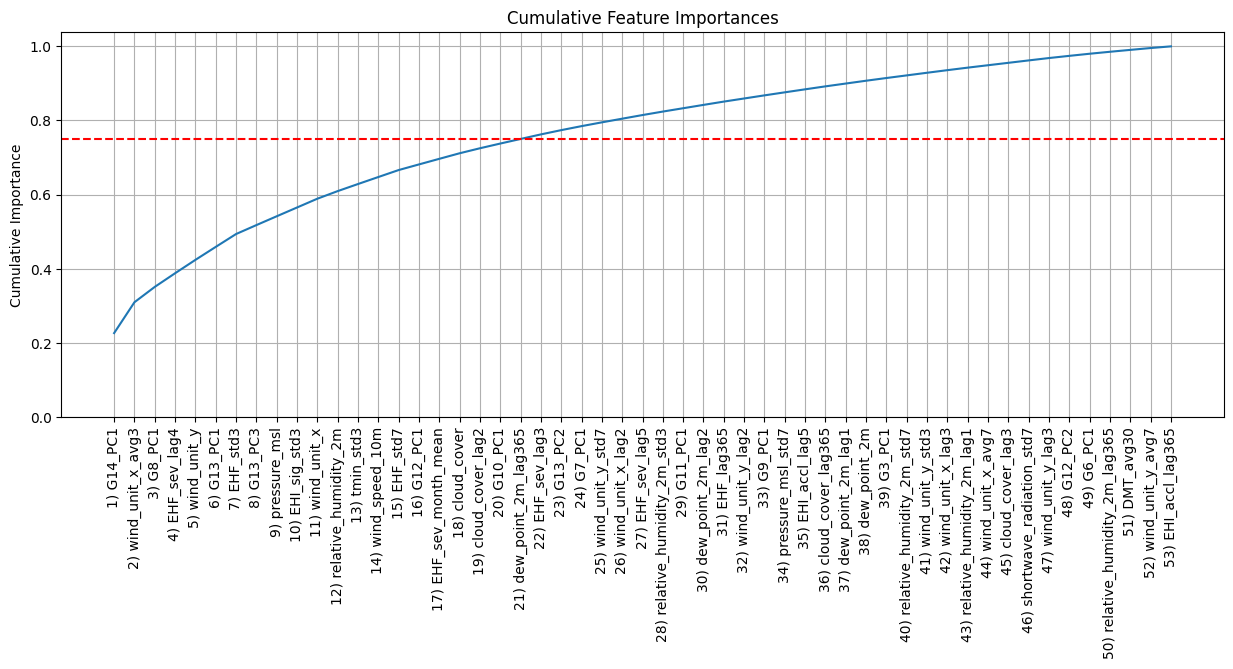

In [ ]:
wasserstein_used_feats = wasserstein_report.loc[wasserstein_report['importance'] > 0, :]
features_with_order = [f"{i}) {c}" for i, c in enumerate(wasserstein_used_feats['feature'], start=1)]
plt.figure(figsize=(15, 5))
plt.title('Cumulative Feature Importances')
plt.plot(np.cumsum(wasserstein_used_feats['importance']))
plt.axhline(y=0.75, color='r', linestyle='--') # 75% boundry
plt.ylim(0)
plt.xticks(range(len(wasserstein_used_feats)), features_with_order, rotation=90)
plt.ylabel('Cumulative Importance')
plt.grid()
# Show the plot
plt.show()

Let's keep model focused concerns aside for now and check the features had high distance values.

In [ ]:
wasserstein_wh_ord = wasserstein_report.sort_values('w_h_mean', ascending=False)
wasserstein_wh_ord

,feature,importance,w_all,w_nh,w_h_mean,w_h_std
142,wind_speed_10m_avg7,0.0000,0.5301,0.5244,0.8160,0.1997
141,wind_speed_10m_std7,0.0000,0.4200,0.4269,0.6613,0.0990
90,wind_unit_y_lag365,0.0000,0.1001,0.1061,0.5932,0.1499
51,wind_unit_y_avg7,0.0050,0.1654,0.1694,0.5798,0.1094
120,EHI_sig_lag5,0.0000,0.0909,0.0708,0.5452,0.0783
...,...,...,...,...,...,...
21,EHF_sev_lag3,0.0123,0.0617,0.0482,0.1731,0.0498
118,precipitation_lag2,0.0000,0.1642,0.1596,0.1560,0.0712
57,month_local,0.0000,0.0000,0.0148,0.1550,0.0843
59,precipitation,0.0000,0.1642,0.1588,0.1479,0.0000


In [ ]:
fg_cls.loc[11, 'feature_group'] # Group 11 features

"['relative_humidity_2m_lag2', 'relative_humidity_2m_lag3', 'relative_humidity_2m_avg3', 'relative_humidity_2m_avg7']"

In [ ]:
fg_cls.loc[10, 'feature_group'] # Group 11 features

"['apparent_temperature_lag365', 'wet_bulb_temperature_2m_lag365', 'DMT_lag365', 'tmin_lag365', 'tmax_lag365', 'EHI_sig_lag365']"

In [ ]:
most_shifted_feats = wasserstein_wh_ord.loc[wasserstein_wh_ord['w_h_mean'] > 0.4, :]['feature']
g13_feats = ast.literal_eval(fg_cls.loc[13, "feature_group"])
print(f"{len(set(g13_feats).intersection(set(most_shifted_feats)))} features of total {len(g13_feats)} 'Group 13' features are among the most shifted features.")

15 features of total 33 'Group 13' features are among the most shifted features.


All feats with `w_h_mean` values higher than 0.4 are almost **3, 7, 365; lag, avg., std. features**. Also, most of them directly related with **temperature, wind** and then **relative humidity.** These are almost all past originated features, they might give insights about next 3-7 days heatwave possibilities and severities. Especially on **wind features** due to:
- They have highest distance values in general.
- They are not directly related with temperature, might reval some additional insights and hypothesis about local wind dynamics.

Because of these facts, these features worth to examine in detail with EHF and severity values. But, because of this notebook about selected models analysis and model calibration, we leave it to future.

# Prediction - EHF / Severity Analysis (Before Tuning)

**! Note:** Analysis made in this section before probability calibration and decision threshold optimization, which means anaylysis based on raw probabilities with default decision threshold (0.5).

In [15]:
# Dataframes for analysis
EHF_info_train = daily_df.loc[y_train.index, ['EHF', 'EHF_sev', 'severity', 'heat_wave']].copy()
EHF_info_test = daily_df.loc[y_test.index, ['EHF', 'EHF_sev', 'severity', 'heat_wave']].copy()
EHF_info_train = pd.concat([EHF_info_train, pd.Series(index=y_train.index, data=artifacts['y_pred_train'], name='prediction')], axis=1)
EHF_info_test = pd.concat([EHF_info_test, pd.Series(index=y_test.index, data=artifacts['y_pred_test'], name='prediction')], axis=1)
EHF_info_train.head()

,EHF,EHF_sev,severity,heat_wave,prediction
datetime_local,,,,,
2001-01-01 00:00:00+10:30,21.467647,0.763525,Low-intensity,True,1.0
2001-01-02 00:00:00+10:30,0.336538,0.011969,Low-intensity,True,0.0
2001-01-03 00:00:00+10:30,-4.195386,0.000000,No-heatwave,False,0.0
2001-01-04 00:00:00+10:30,-4.162083,0.000000,No-heatwave,False,0.0
2001-01-05 00:00:00+10:30,-4.912083,0.000000,No-heatwave,False,0.0


In [16]:
train_correct_preds = EHF_info_train.loc[EHF_info_train['heat_wave'] == EHF_info_train['prediction']]
test_correct_preds = EHF_info_test.loc[EHF_info_test['heat_wave'] == EHF_info_test['prediction']]
train_wrong_preds = EHF_info_train.loc[EHF_info_train['heat_wave'] != EHF_info_train['prediction']]
test_wrong_preds = EHF_info_test.loc[EHF_info_test['heat_wave'] != EHF_info_test['prediction']]

In [17]:
# Generating severity prediction count tables
train_count_table = EHF_info_train['severity'].value_counts().to_frame().join(
    pd.concat([train_correct_preds['severity'].value_counts(), 
               train_wrong_preds['severity'].value_counts()],
              axis=1,
              keys=['correct', 'wrong']
    )
).fillna(0)
train_count_table['severity_recall'] = train_count_table['correct'] / train_count_table['count']

test_count_table = EHF_info_test['severity'].value_counts().to_frame().join(
    pd.concat([test_correct_preds['severity'].value_counts(), 
               test_wrong_preds['severity'].value_counts()],
              axis=1,
              keys=['correct', 'wrong']
    )
).fillna(0)
test_count_table['severity_recall'] = test_count_table['correct'] / test_count_table['count']

In [18]:
train_count_table

,count,correct,wrong,severity_recall
severity,,,,
No-heatwave,6981,6967,14.0,0.997995
Low-intensity,273,230,43.0,0.842491
Severe,46,46,0.0,1.000000
Extreme,5,5,0.0,1.000000


In [ ]:
test_count_table

,count,correct,wrong,severity_recall
severity,,,,
No-heatwave,1423,1415,8.0,0.994378
Low-intensity,32,15,17.0,0.468750
Severe,6,6,0.0,1.000000


As we can see; model has been able to detect almost all train set heatwaves, it missed ~15% of *Low-intensity* heatwaves. In the mean time, it missed a little more than half of of the test set *Low-intensity* heatwaves. Good thing model has been able to detect all severe and extreme heatwaves in both sets. They are the ones have drastic effects on organic (e.g. humans, wildlife) and inorganic (e.g. environment, energy grid system) structures.

Let's check which EHF intervals have been missed by our model.

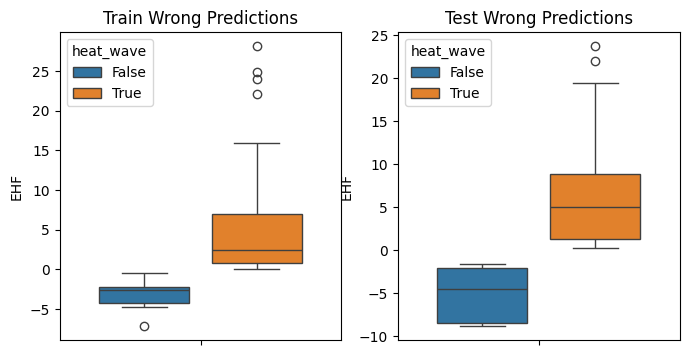

In [20]:
fig, ax = plt.subplots(1, 2)
fig.set_size_inches(8, 4)
sns.boxplot(data=train_wrong_preds, y='EHF', hue='heat_wave', ax=ax[0], gap=0.2, legend='brief')
sns.boxplot(data=test_wrong_preds, y='EHF', hue='heat_wave', ax=ax[1], gap=0.2, legend='brief')
ax[0].set_title("Train Wrong Predictions")
ax[1].set_title("Test Wrong Predictions")
plt.show()

* Models wrong interval around **EHF=0**. Which is good thing, due to it works interpretable way and wrong predictions are all around threshold. That means in overall, wrong predicted `No-heatwave` days close to be a `Low-intensity` heatwave day, and vice versa, wrong predicted `Low-intensity` days close to be a `No-heatwave` heatwave. Thus, in practice, wrong predcitions would not cause big problems. If we set decision threshold in favor of *heatwaves*, models precision would drop. Which means wrong predicted `Low-intensity` counts would decrease as `No-heatwave` counts increase. But wrong predicted `No-heatwave` instances would close to be an actual heatwave event.

* Also, we are predicting probabilities. We are going to do **probability calibration** in the next notebook. Calibrated probabilities and EHF values can have a relation, we'll check that. In any case, let's check raw probabilities too, to see how model seperates heatwaves and non-heatwaves.

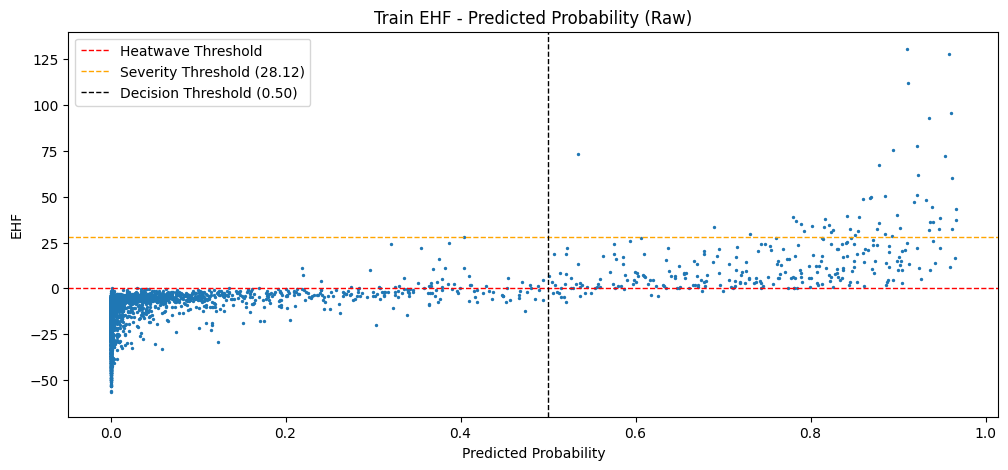

In [21]:
plot_ehf_proba(artifacts['y_score_train'], EHF_info_train['EHF'], 'Train EHF - Predicted Probability (Raw)')

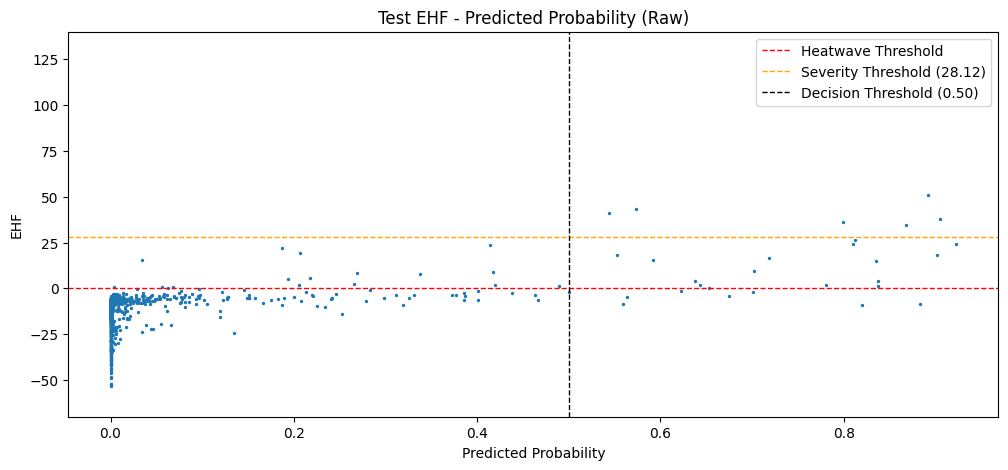

In [22]:
plot_ehf_proba(artifacts['y_score_test'], EHF_info_test['EHF'], 'Test EHF - Predicted Probability (Raw)')

Learned pattern fits the trend that as probability increases, possible EHF values are increasing too. Test set seems has similar pattern too, but because of the facts those it has very low amount of heatwave days, and our model has slight overfitting; we can't be sure pattern is consistent as we have in train set. Still plot is in favor of the pattern at some degree. In the other hand, these are still not calibrated probabilities, they might show more optimistic and supporting pattern.

# Probability Calibration

In this section, we are going to calibrate our model's probabilities. We are going to use **Platt Scaling** method with *cross validation*. For rare event context and sufficiently large data, using **Isotonic Regression** might be more appropriate. But, our data size is not large enough for this, hence the chosen method.

We are going to use **Calibration/Reliability Curves**, **Expected Calibration Error (ECE)** and **Brier Score** to analyze, compare raw and calibrated probabilities. **!** *Brier Score* is not directly a measure of probability calibration, but its one of 3-component decomposition parts is *Reliability*. Which is squared version of *ECE*. *ECE* takes absolute of difference of bin's average accuracy and average confidence.

**References for these measures:**
- [Expected Calibration Error](https://medium.com/data-science/expected-calibration-error-ece-a-step-by-step-visual-explanation-with-python-code-c3e9aa12937d)
- [Brier Score](https://en.wikipedia.org/wiki/Brier_score)

In [ ]:
xgb_calib = XGBCalibrated(params=params, n_splits=5, test_size=(365*2), random_state=RANDOM_STATE)

# Fit and calibrate
xgb_calib.fit_and_calibrate(
    X_train=X_train, 
    y_train=y_train, 
    X_test=X_test,
    feature_groups_df=fg_cls, 
    non_standardized_features= non_standardized_features, 
    features_not_to_be_used=not_to_be_used_at_nonlinear
)

We implemented a custom XGBoost model class that can be calibrated. This custom model can yield probabilities and predictions by raw or calibrated. We are going to compare raw and calibrated probabilities.

In [34]:
# Base XGB probabilities
train_proba_raw = xgb_calib.predict_proba_raw(X_train)
test_proba_raw = xgb_calib.predict_proba_raw(X_test)

# Calibrated XGB probabilities
train_proba_calib = xgb_calib.predict_proba_calib(X_train)
test_proba_calib = xgb_calib.predict_proba_calib(X_test)

**Raw Probaility Analysis**

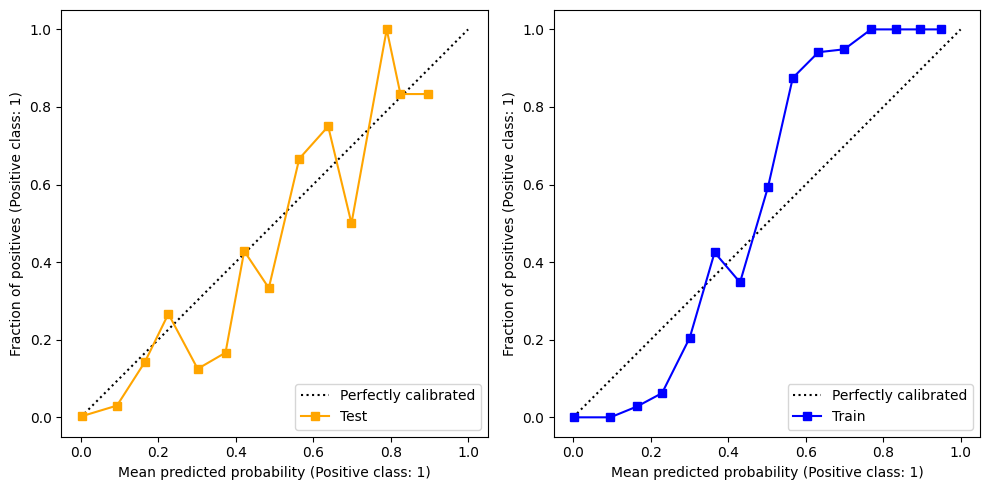

In [15]:
plot_calibration_curves(y_test, test_proba_raw[:, 1], y_train, train_proba_raw[:, 1], n_bins=15)

In [16]:
raw_test_ece = expected_calibration_error(samples=test_proba_raw, true_labels=y_test, n_bins=10)[0].round(4)
raw_train_ece = expected_calibration_error(samples=train_proba_raw, true_labels=y_train, n_bins=10)[0].round(4)
print("Raw Probability Prediction Metrics")
print(f"Test ECE: {raw_test_ece}")
print(f"Train ECE: {raw_train_ece}")
print(f"Test Brier: {np.round(brier_score_loss(y_test, test_proba_raw[:, 1]), 4)}")
print(f"Train Brier: {np.round(brier_score_loss(y_train, train_proba_raw[:, 1]), 4)}")

Raw Probability Prediction Metrics
Test ECE: 0.0033
Train ECE: 0.0165
Test Brier: 0.0133
Train Brier: 0.0082


When we look at curves and measures, base model seems actually calibrated well enough, even without any calibration. ! Careful, we should be looking test set performances rather than train set. Train set performances displayed due to demonstration purposes.

**Calibrated Probability Analysis**

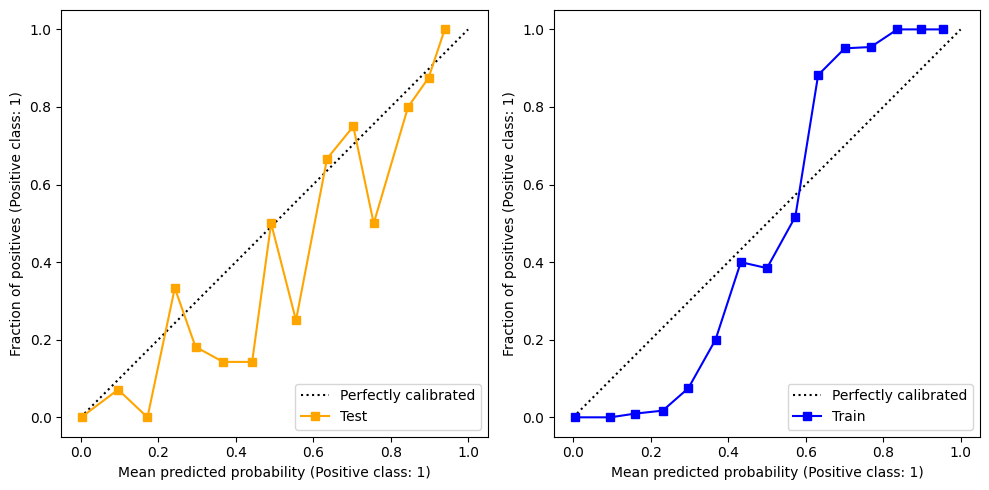

In [16]:
plot_calibration_curves(y_test, test_proba_calib[:, 1], y_train, train_proba_calib[:, 1], n_bins=15)

In [35]:
calib_test_ece = expected_calibration_error(samples=test_proba_calib, true_labels=y_test, n_bins=10)[0].round(4)
calib_train_ece = expected_calibration_error(samples=train_proba_calib, true_labels=y_train, n_bins=10)[0].round(4)
print(f"Test ECE: {calib_test_ece}")
print(f"Train ECE: {calib_train_ece}")
print(f"Test Brier: {np.round(brier_score_loss(y_test, test_proba_calib[:, 1]), 4)}")
print(f"Train Brier: {np.round(brier_score_loss(y_train, train_proba_calib[:, 1]), 4)}")

Test ECE: 0.0069
Train ECE: 0.0179
Test Brier: 0.0138
Train Brier: 0.0083


Here there are several catches: Train set ECE and Brier slighlty lower than test sets'. Still acceptable. **BUT!:** When we compare plots, calibrated model deviates more from the ideal curve. And here plots are more important than numerical metrics in our context:

**!!!** Both metrics calculated by taking average. Our main modelling goal is *rare event detection*. So, negative instances covers a lot, also covers biggest portion of scores too. However, plots show us local performances beside overall performance. To demonstrate this problem better, let's display **EHF - Predicted Probability** scatter plots. 

(Please, head down below the following plots for analysis.)

In [30]:
# Dataframes for analysis
EHF_info_train = daily_df.loc[y_train.index, ['EHF', 'EHF_sev', 'severity', 'heat_wave']].copy()
EHF_info_test = daily_df.loc[y_test.index, ['EHF', 'EHF_sev', 'severity', 'heat_wave']].copy()

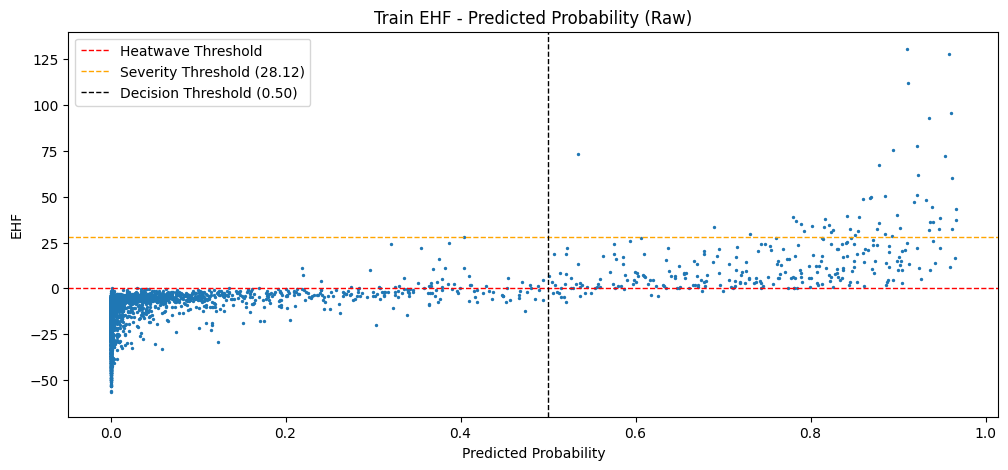

In [19]:
plot_ehf_proba(train_proba_raw[:, 1], EHF_info_train['EHF'], 'Train EHF - Predicted Probability (Raw)')

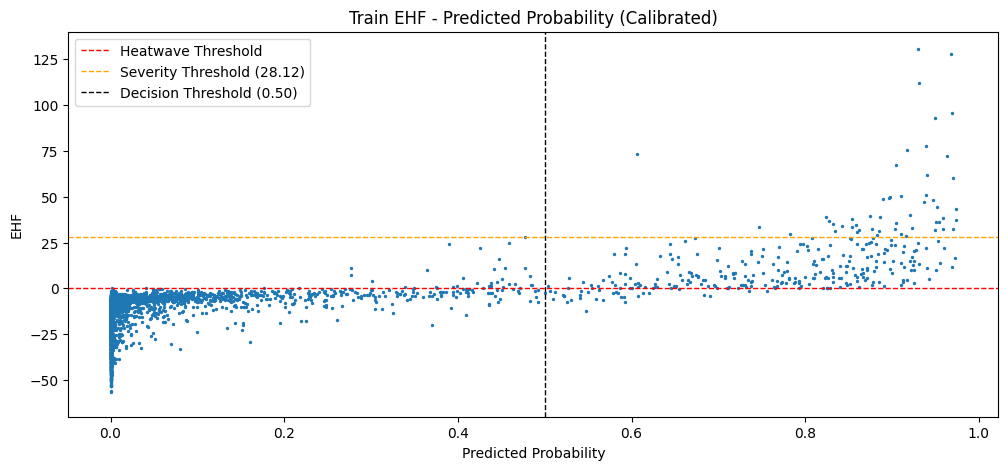

In [20]:
plot_ehf_proba(train_proba_calib[:, 1], EHF_info_train['EHF'], 'Train EHF - Predicted Probability (Calibrated)')

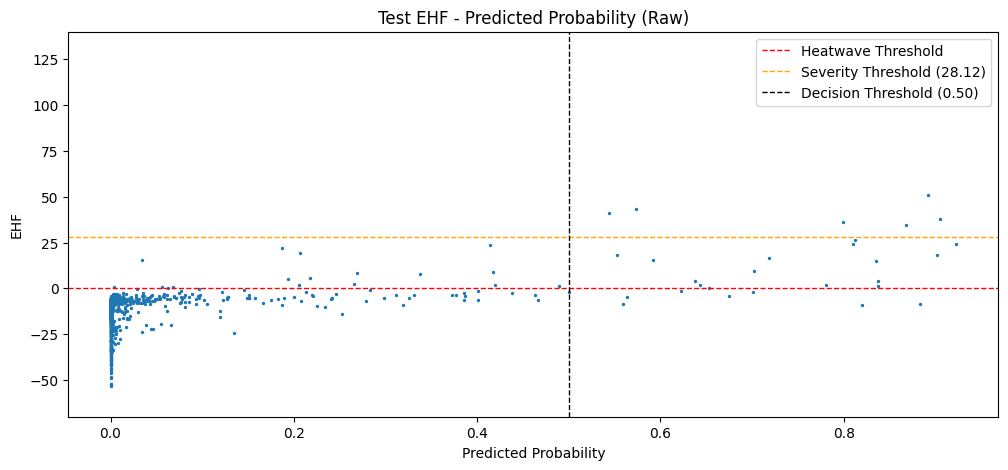

In [21]:
plot_ehf_proba(test_proba_raw[:, 1], EHF_info_test['EHF'], 'Test EHF - Predicted Probability (Raw)')

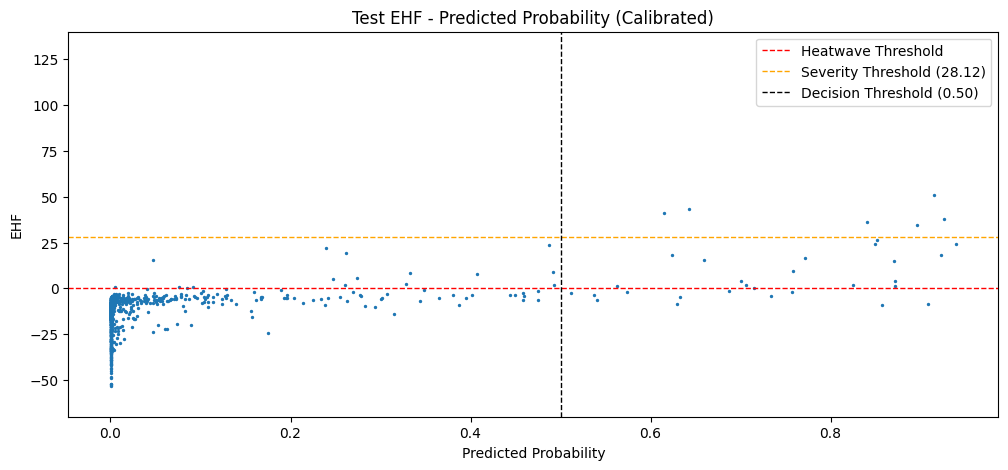

In [22]:
plot_ehf_proba(test_proba_calib[:, 1], EHF_info_test['EHF'], 'Test EHF - Predicted Probability (Calibrated)')

As we can see in each plot negative instances are cumulated on $[0, 0.1]$ interval. This fact causes ECE and Brier scores to be pulled down. Because most of the instances are correctly positioned. In this case trusting only these two score would be analogous with trusting *accuracy* as a model performance metric. Thus, we are going to inspect at each bins' errors and their weights. And take the average of weighted errors after cumulated negative instance bin(s). 

We are going to use `ece_binary_with_bins()` function. Unlike *ECE* uses predicted class probabilities as confidences, this function uses conditional probabilities of being positive class. Thus, it can be used only for binary classification problems.

In [21]:
ece_tr_raw, err_tr_raw, weights_tr_raw, _, _ = ece_binary_with_bins(train_proba_raw[:, 1], y_train, n_bins=10)
ece_ts_raw, err_ts_raw, weights_ts_raw, _, _ = ece_binary_with_bins(test_proba_raw[:, 1], y_test, n_bins=10)
ece_tr_calib, err_tr_calib, weights_tr_calib, _, _ = ece_binary_with_bins(train_proba_calib[:, 1], y_train, n_bins=10)
ece_ts_calib, err_ts_calib, weights_ts_calib, _, _ = ece_binary_with_bins(test_proba_calib[:, 1], y_test, n_bins=10)
pd.DataFrame({
    'Bin': range(1, 11),
    'Raw Test Error': err_ts_raw.round(4),
    'Raw Test Weight': weights_ts_raw.round(4),
    'Calib. Test Error': err_ts_calib.round(4),
    'Calib. Test Weight': weights_ts_calib.round(4),
    'Raw Train Error': err_tr_raw.round(4),
    'Raw Train Weight': weights_tr_raw.round(4),
    'Calib. Train Error': err_tr_calib.round(4),
    'Calib. Train Weight': weights_tr_calib.round(4),
})

,Bin,Raw Test Error,Raw Test Weight,Calib. Test Error,Calib. Test Weight,Raw Train Error,Raw Train Weight,Calib. Train Error,Calib. Train Weight
0,1,0.0009,0.9377,0.0011,0.9247,0.0044,0.9166,0.0049,0.9058
1,2,0.0635,0.0164,0.1407,0.0240,0.1249,0.0208,0.1351,0.0249
2,3,0.0251,0.0130,0.0229,0.0123,0.1507,0.0089,0.2054,0.0107
3,4,0.2531,0.0068,0.1772,0.0082,0.0072,0.0085,0.2032,0.0075
4,5,0.0099,0.0062,0.1263,0.0082,0.0763,0.0048,0.0114,0.0073
5,6,0.0164,0.0048,0.3461,0.0034,0.2603,0.0071,0.0932,0.0059
6,7,0.0460,0.0034,0.0707,0.0048,0.2749,0.0074,0.2333,0.0071
7,8,0.0598,0.0034,0.0205,0.0048,0.2462,0.0088,0.2179,0.0090
8,9,0.0660,0.0062,0.0302,0.0062,0.1519,0.0116,0.1465,0.0136
9,10,0.0902,0.0021,0.1221,0.0034,0.0684,0.0055,0.0653,0.0082


We can see that instances cumulated in first bin for each four predicted probabailities. We are going to take weighted average after first bin. But before we do that, if we check test error values for both *raw* and *calibrated* probabilities, errors are acceptable at overall. Additionally by counting on above plots, calibrated model tend to more overconfident on some bins than raw model. Let's check weighted averages of test errors after first bins and see which model is more calibrated at overall.

In [74]:
partial_test_ece_raw = np.sum(err_ts_raw[1:] * weights_ts_raw[1:]) / np.sum(weights_ts_raw[1:])
partial_test_ece_calib = np.sum(err_ts_calib[1:] * weights_ts_calib[1:]) / np.sum(weights_ts_calib[1:])

print(f"Raw Partial Test ECE: {partial_test_ece_raw.round(5)}")
print(f"Calibrated Partial Test ECE: {partial_test_ece_calib.round(5)}")

Raw Partial Test ECE: 0.06734
Calibrated Partial Test ECE: 0.10711


**Result:** Thus, we can see that our base model has better calibration than calibrated model. In this case, using raw probabilities would be more accurate in general. Or, we can take each probabilities, compare and choose the best one in terms of local calibration accuracies, by checking bin errors. 

# Probability - EHF / Severity Analysis

We've done *"Prediction - EHF / Severity Analysis"* before at above section. We've found out that model can detect *severe and extreme* heatwaves in both train and test sets. Also model's predicted raw probabilities show a positive trend with EHF values, which is good thing interprebability and predicting the severity of upcoming heatwaves. We've found out raw probabilities are more calibrated than calibrated probabilities at just above. So, we should focus on thie analysis and interpretation. But eventually, we want to get both probability and compare, interpret together to make more reliable decision. Thus, we'll check each probability groups' severity distributions.

In [ ]:
def probability_severity_distribution(df_train, df_test, title):
    colors = {"No-heatwave": "green", "Low-intensity": "yellow", "Severe": "orange", "Extreme": "red"}
    fig, ax = plt.subplots(1, 2)
    fig.set_size_inches(12, 4)
    sns.boxplot(data=df_train, y='proba', hue='severity', ax=ax[0], palette=colors, gap=0.2, legend='brief')
    sns.boxplot(data=df_test, y='proba', hue='severity', ax=ax[1], palette=colors, gap=0.2, legend='brief')
    plt.suptitle(title)
    ax[0].set_title("Train")
    ax[1].set_title("Test")
    plt.show()

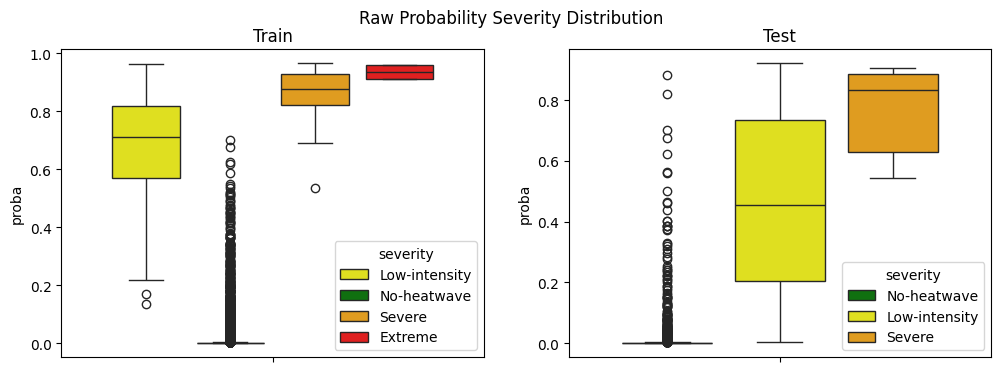

In [42]:
EHF_info_train_raw = pd.concat([EHF_info_train, pd.Series(index=y_train.index, data=train_proba_raw[:, 1], name='proba')], axis=1)
EHF_info_test_raw = pd.concat([EHF_info_test, pd.Series(index=y_test.index, data=test_proba_raw[:, 1], name='proba')], axis=1)
probability_severity_distribution(EHF_info_train_raw, EHF_info_test_raw, "Raw Probability Severity Distribution")

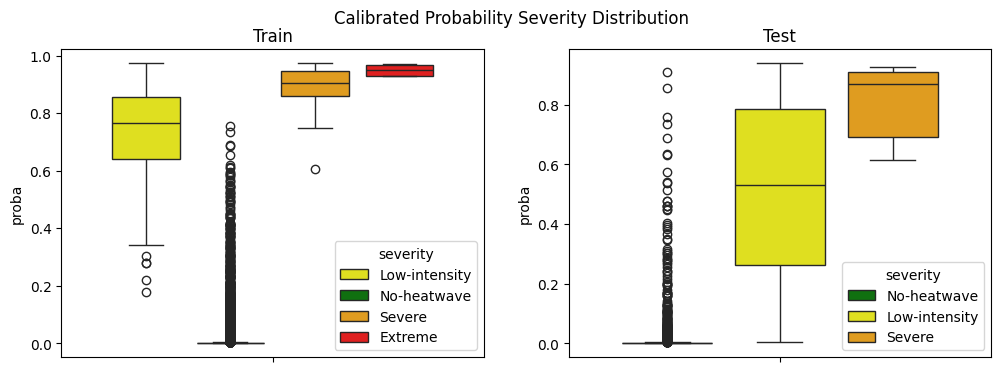

In [41]:
EHF_info_train_calib = pd.concat([EHF_info_train, pd.Series(index=y_train.index, data=train_proba_calib[:, 1], name='proba')], axis=1)
EHF_info_test_calib = pd.concat([EHF_info_test, pd.Series(index=y_test.index, data=test_proba_calib[:, 1], name='proba')], axis=1)
probability_severity_distribution(EHF_info_train_calib, EHF_info_test_calib, "Calibrated Probability Severity Distribution")

We can see for both probabilitiy group, **severe** and **extreme** events gathered at higher and shallow intervals. Train-test set intervals don't mathc perfectly but definetely similar. **!** Also here we see spesific benefit of *calibrated probabilities*, that their *severe* and *extreme* intervals are gathered more higher and shallow than raw probabilities, because they are overconfident at some local areas. This fact would be useful for predicting severity and decision making. 

In [47]:
EHF_info_test_raw[['severity', 'proba']].groupby('severity').describe().round(4)

proba                                                        
                count    mean     std     min     25%     50%     75%     max
severity                                                                     
Low-intensity    32.0  0.4713  0.2965  0.0037  0.2061  0.4546  0.7337  0.9225
No-heatwave    1423.0  0.0163  0.0698  0.0001  0.0002  0.0003  0.0011  0.8834
Severe            6.0  0.7636  0.1630  0.5441  0.6300  0.8336  0.8854  0.9054

In [48]:
EHF_info_test_calib[['severity', 'proba']].groupby('severity').describe().round(4)

proba                                                        
                count    mean     std     min     25%     50%     75%     max
severity                                                                     
Low-intensity    32.0  0.5202  0.2983  0.0054  0.2629  0.5291  0.7850  0.9392
No-heatwave    1423.0  0.0202  0.0806  0.0002  0.0004  0.0005  0.0016  0.9082
Severe            6.0  0.8059  0.1400  0.6158  0.6925  0.8679  0.9099  0.9257

If we look directly exact numerical ranges: If predicted **raw probability greater than 0.5** and **calibrated probability greater than 0.6**, then we can say that heatwave severity might be **severe** or more. Also by counting on *"Test EHF - Predicted Probability (Raw)"* and *"Test EHF - Predicted Probability (Calibrated)"* plots as probability increases, probability of being *severe* or *extreme* heatwaves increases too. Lastly, by counting train set probability-severity distribution plots above, we can anticipate **extreme** heatwaves **after 0.75, 0.8** predicted probability. Keeping threshold wider due to we can emprically see test sets' probability severity ranges similar to train set but wider than them.

# Decision Threshold Tuning

We are going to find best threshold under a minimum precision constraint to maximize recall by cross-validation. We use precision constraint to avoid a lot of false alarms, because we want to keep our model's reliability high as possible while we keep its event detection power high as well. We use here raw prediction scores, not calibrated probabilities. We can't use them with our threshold optimization method together. The reason is; to complete calibration of a model, we need to complete whole CV. But, when we optimizing threshold, we get each CV folds' threshold. Thus, it is impossible to make it work this both CV processes together.

**!** Although, even if they would work, we still don't have to use calibrated probabilities: Because calibration process saves raw probabilities' structural hierarchy. Which means, their score order is not changed. What calibration does is, it either narrows or stretches local intervals of the whole data point score structure to match them with their actual local positive rates. In this case, we can still optimize threshold with raw probabilities. We can get same results with calibrated probabilities by find its equivalent threshold value.    

In [ ]:
# Maximize Recall with subject to Precision greater than equals to 0.4
threshold_cv_result_df_04, fold_metrics_with_thresholds_04 = optimize_threshold_cv(
        model_class=XGBClassifier,
        model_params=params, # ! RANDOM STATE is passed in `params`.
        X_train=X_train, 
        y_train=y_train, 
        feature_groups_df=fg_cls, 
        non_standardized_features=non_standardized_features,
        features_not_to_be_used=not_to_be_used_at_nonlinear,
        cv_splits=5,
        precision_limit=0.4
)

# Maximize Recall with subject to Precision greater than equals to 0.5
threshold_cv_result_df_05, fold_metrics_with_thresholds_05 = optimize_threshold_cv(
        model_class=XGBClassifier,
        model_params=params,
        X_train=X_train, 
        y_train=y_train, 
        feature_groups_df=fg_cls, 
        non_standardized_features=non_standardized_features,
        features_not_to_be_used=not_to_be_used_at_nonlinear,
        cv_splits=5,
        precision_limit=0.5
)

In [37]:
# Precision > 0.4 CV Results
threshold_cv_result_df_04

,fold,best_threshold,best_precision,best_recall
0,1,0.077109,0.400000,0.956522
1,2,0.038994,0.400000,0.923077
2,3,0.043656,0.400000,1.000000
3,4,0.041897,0.402299,0.921053
4,5,0.090028,0.402778,0.935484


In [39]:
print("------Summary Results with Subject to Precision > 0.4------")
print(f"Mean Best Precision: {threshold_cv_result_df_04['best_precision'].mean().__round__(4)} +/- {threshold_cv_result_df_04['best_precision'].std().__round__(4)}")
print(f"Mean Best Recall: {threshold_cv_result_df_04['best_recall'].mean().__round__(4)} +/- {threshold_cv_result_df_04['best_recall'].std().__round__(4)}")
print(f"Mean Best Threshold: {threshold_cv_result_df_04['best_threshold'].mean().__round__(4)} +/- {threshold_cv_result_df_04['best_threshold'].std().__round__(4)}")

------Summary Results with Subject to Precision > 0.4------
Mean Best Precision: 0.401 +/- 0.0014
Mean Best Recall: 0.9472 +/- 0.0327
Mean Best Threshold: 0.05829999968409538 +/- 0.023499999195337296


In [40]:
# Precision > 0.5 CV Results
threshold_cv_result_df_05

,fold,best_threshold,best_precision,best_recall
0,1,0.123817,0.5,0.913043
1,2,0.154812,0.5,0.820513
2,3,0.150242,0.5,0.794118
3,4,0.104281,0.5,0.815789
4,5,0.180328,0.5,0.870968


In [41]:
print("------Summary Results with Subject to Precision > 0.5------")
print(f"Mean Best Precision: {threshold_cv_result_df_05['best_precision'].mean().__round__(4)} +/- {threshold_cv_result_df_05['best_precision'].std().__round__(4)}")
print(f"Mean Best Recall: {threshold_cv_result_df_05['best_recall'].mean().__round__(4)} +/- {threshold_cv_result_df_05['best_recall'].std().__round__(4)}")
print(f"Mean Best Threshold: {threshold_cv_result_df_05['best_threshold'].mean().__round__(4)} +/- {threshold_cv_result_df_05['best_threshold'].std().__round__(4)}")

------Summary Results with Subject to Precision > 0.5------
Mean Best Precision: 0.5 +/- 0.0
Mean Best Recall: 0.8429 +/- 0.0483
Mean Best Threshold: 0.14270000159740448 +/- 0.029400000348687172


For both precision bottom threshold, we've got good results. We can use mean of CV best threshold values. Let's check the full train set metrics with this thresholds. 

We can use `XGBCalibrated` model to make predictions with spesific thresholds. It handles input data preprocessing for us.

In [42]:
threshold_04 = threshold_cv_result_df_04['best_threshold'].mean()
threshold_05 = threshold_cv_result_df_05['best_threshold'].mean()

In [43]:
train_pred_04 = xgb_calib.predict_raw(X_train, threshold=threshold_04)
metric_result_train_04, _, _ = get_classification_metrics(y=y_train, y_pred=train_pred_04, y_score=train_proba_raw[:, 1])

test_pred_04 = xgb_calib.predict_raw(X_test, threshold=threshold_04)
metric_result_test_04, _, _ = get_classification_metrics(y=y_test, y_pred=test_pred_04, y_score=test_proba_raw[:, 1])

train_pred_05 = xgb_calib.predict_raw(X_train, threshold=threshold_05)
metric_result_train_05, _, _ = get_classification_metrics(y=y_train, y_pred=train_pred_05, y_score=train_proba_raw[:, 1])

test_pred_05 = xgb_calib.predict_raw(X_test, threshold=threshold_05)
metric_result_test_05, _, _ = get_classification_metrics(y=y_test, y_pred=test_pred_05, y_score=test_proba_raw[:, 1])

In [44]:
print("-------Threshold with Precision > 0.4-------")
print(f"Train Recall: {metric_result_train_04['recall']:.4f} - Train Precision: {metric_result_train_04['precision']:.4f}")
print(f"Test Recall: {metric_result_test_04['recall']:.4f} - Test Precision: {metric_result_test_04['precision']:.4f}")
print("")
print("-------Threshold with Precision > 0.5-------")
print(f"Train Recall: {metric_result_train_05['recall']:.4f} - Train Precision: {metric_result_train_05['precision']:.4f}")
print(f"Test Recall: {metric_result_test_05['recall']:.4f} - Test Precision: {metric_result_test_05['precision']:.4f}")

-------Threshold with Precision > 0.4-------
Train Recall: 1.0000 - Train Precision: 0.4286
Test Recall: 0.9211 - Test Precision: 0.2893

-------Threshold with Precision > 0.5-------
Train Recall: 0.9969 - Train Precision: 0.6224
Test Recall: 0.8684 - Test Precision: 0.4125


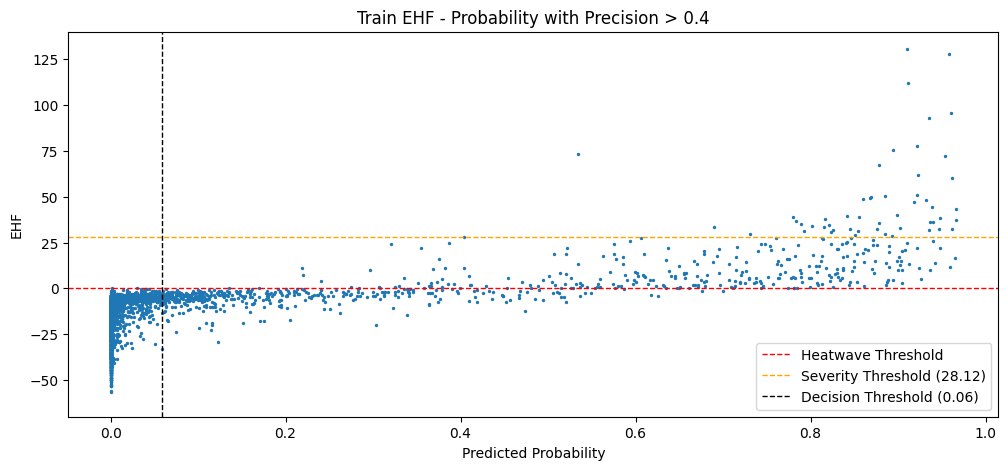

In [45]:
plot_ehf_proba(train_proba_raw[:, 1], EHF_info_train['EHF'], 'Train EHF - Probability with Precision > 0.4', 
               decision_threshold=threshold_04)

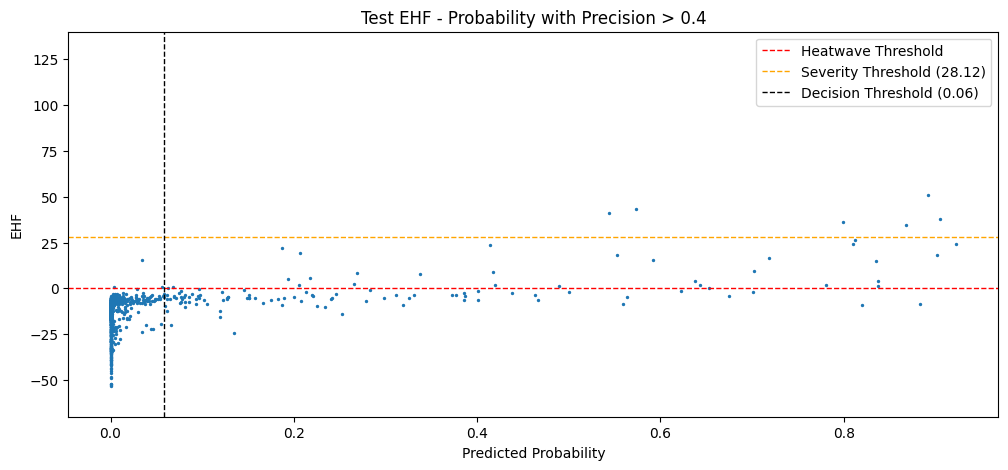

In [46]:
plot_ehf_proba(test_proba_raw[:, 1], EHF_info_test['EHF'], 'Test EHF - Probability with Precision > 0.4', 
               decision_threshold=threshold_04)

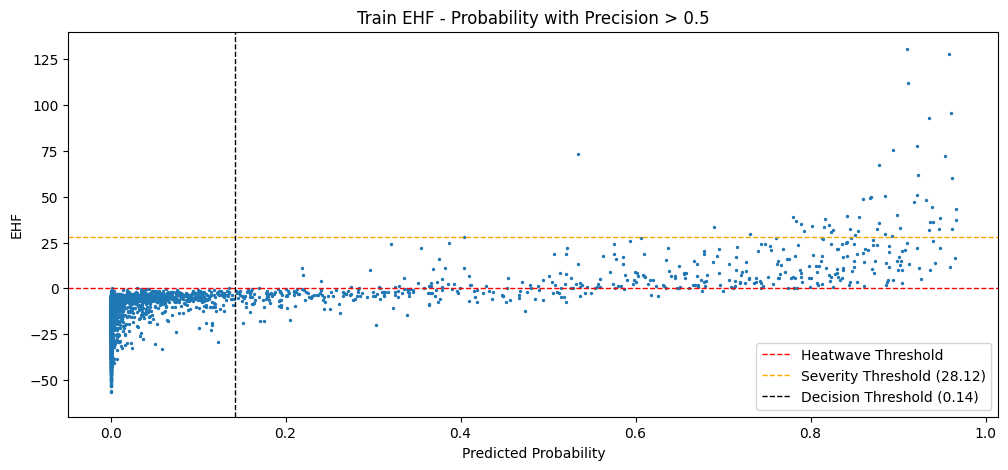

In [47]:
plot_ehf_proba(train_proba_raw[:, 1], EHF_info_train['EHF'], 'Train EHF - Probability with Precision > 0.5',
               decision_threshold=threshold_05)

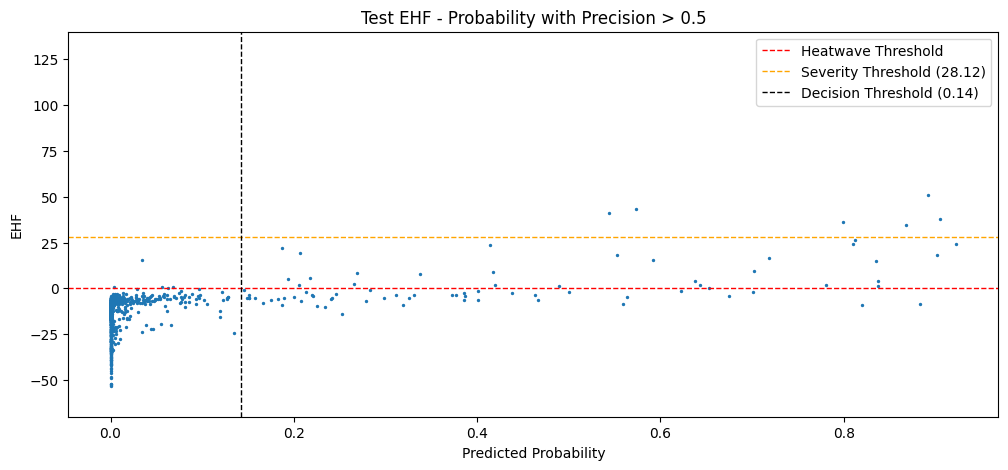

In [48]:
plot_ehf_proba(test_proba_raw[:, 1], EHF_info_test['EHF'], 'Test EHF - Probability with Precision > 0.5', 
               decision_threshold=threshold_05)

When we look at plots, precisions and recalls with these two threshold, *threshold with precision > 0.5* is seems reasonable. Because in each case, almost all heatwaves detected and wasn't missed any high EHF / severe heatwaves. So, we can just use the threshold with better precision values. Also, if we spesifically look this thresholds plots, they are cut from points where heatwaves start to occur in both train and test sets. By visuals, we might try a little bit higher precision constraint threshold, however it would be aginst generalization because it would be kind of selection bias. Eventually, we fix our threshold to:

In [49]:
print(f"threshold with Precision > 0.5: {threshold_05}.")

threshold with Precision > 0.5: 0.1426960825920105.


Let's check wrong prediction distributions with this threshold.

In [50]:
# Assigning optimized threshold predictions
EHF_info_train['prediction'] = train_pred_05
EHF_info_test['prediction'] = test_pred_05

In [51]:
train_correct_preds = EHF_info_train.loc[EHF_info_train['heat_wave'] == EHF_info_train['prediction']]
test_correct_preds = EHF_info_test.loc[EHF_info_test['heat_wave'] == EHF_info_test['prediction']]
train_wrong_preds = EHF_info_train.loc[EHF_info_train['heat_wave'] != EHF_info_train['prediction']]
test_wrong_preds = EHF_info_test.loc[EHF_info_test['heat_wave'] != EHF_info_test['prediction']]

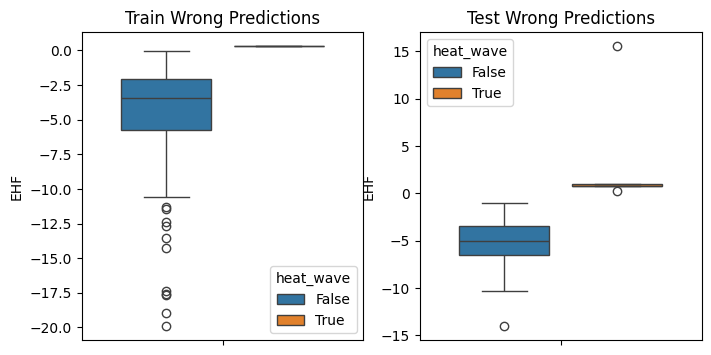

In [52]:
fig, ax = plt.subplots(1, 2)
fig.set_size_inches(8, 4)
sns.boxplot(data=train_wrong_preds, y='EHF', hue='heat_wave', ax=ax[0], gap=0.2, legend='brief')
sns.boxplot(data=test_wrong_preds, y='EHF', hue='heat_wave', ax=ax[1], gap=0.2, legend='brief')
ax[0].set_title("Train Wrong Predictions")
ax[1].set_title("Test Wrong Predictions")
plt.show()

We've sacrificed prediction precision in order to increase detection rate.

# Outro and Conclusion

In this notebook: 
* We've find out there is not a significant shift between train and test sets that might cause bad performance for our model. Due to its preference of feature sets. This is in favor of our models generalization and robustness.
* We've find out our model seperates heatwaves and non-heatwaves from the *EHF=0* transition zone, which makes our model more interpretable. Also, predicsts severe and extreme heatwaves with higher confidence and, detected all of them in both train and test sets.
* We've find out that our selected model's raw probabilities are well calibrated than calibrated probabilities. Although, we can still check them and produced **probability / EHF plots** as supporting evidence.
* We've optimized our model's decision threshold with subject to *Precision > 0.5* constraint by cross-validation. As result, we've got **Test Recall: 0.8684 - Test Precision: 0.4125**. Additionally, with detail of missed events are all *Low-intensity* heatwaves, which is good.

This was the last notebook of our Heatwave Detection Project. There are things we might do in the future: 
* Like there was a few questions and hypotheses through notebooks, like we've got an at the end of `Feature Distribution Analysis` section in this notebook. We can research on them in the future, whether in this project / repository or another else.
* Other one and actually more obvious one is, we can fetch and process the data from 2024 to current day and, predict those days' are heatwave or not. This would be a applicative level demonstration of our model. On top of that, we can optimize workflow and deploy it as a basic web application. 

For now, it is end of the project.

**! TO THE READER:**  I thank you for your attention, even it was a bit. But, if you really read and looked through all project notebooks, I sincerely thank you and respect you! :D

# Bottom